# Retail Sales - Exploratory Data Analysis (EDA) Mini Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# just some notebook-wide settings so the charts look decent
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


## 1. Loading the Data + First Look



In [2]:
df = pd.read_csv("retail_sales_data.csv")
df.shape


(9815, 22)

In [3]:
df.head()


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Age,Gender,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,ORD-2022-003221,2022-01-01,2022-01-07,Standard Class,CUST-00461,Wei Singh,61.0,Male,Consumer,United States,Houston,Ohio,28031.0,Central,PRD-4700,Office Supplies,Storage,Binder Organizer,104.19,2,0.30,6.13
1,ORD-2022-001096,2022-01-01,2022-01-03,Standard Class,CUST-01210,Charles Khan,48.0,Male,Consumer,United States,Nashville,Tennessee,37731.0,South,PRD-3207,Furniture,Furnishings,Desk Lamp,30.25,1,0.20,1.12
2,ORD-2022-005393,2022-01-01,2022-01-06,Standard Class,CUST-01178,John Miller,20.0,Female,Home Office,United States,Detroit,Texas,90883.0,Central,PRD-4700,Office Supplies,Storage,Binder Organizer,372.22,6,NaN,49.08
3,ORD-2022-006796,2022-01-01,2022-01-05,Second Class,CUST-00793,Priya Garcia,22.0,Male,Consumer,United States,Philadelphia,Massachusetts,46666.0,East,PRD-5039,Office Supplies,Labels,Address Labels,9.36,1,0.05,1.40
4,ORD-2022-007006,2022-01-01,2022-01-03,First Class,CUST-00491,Priya Wilson,63.0,Female,Consumer,United States,Newark,Massachusetts,74640.0,East,PRD-2676,Furniture,Chairs,Mesh Office Chair,129.05,1,0.40,-21.99


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9815 entries, 0 to 9814
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9815 non-null   str    
 1   Order Date     9815 non-null   str    
 2   Ship Date      9815 non-null   str    
 3   Ship Mode      9815 non-null   str    
 4   Customer ID    9815 non-null   str    
 5   Customer Name  9815 non-null   str    
 6   Age            9785 non-null   float64
 7   Gender         9815 non-null   str    
 8   Segment        9815 non-null   str    
 9   Country        9815 non-null   str    
 10  City           9815 non-null   str    
 11  State          9815 non-null   str    
 12  Postal Code    9755 non-null   float64
 13  Region         9815 non-null   str    
 14  Product ID     9815 non-null   str    
 15  Category       9815 non-null   str    
 16  Sub-Category   9815 non-null   str    
 17  Product Name   9815 non-null   str    
 18  Sales          9815

**Observation:**
The dataset has **9,815 rows and 22 columns**. There's a mix of:
- IDs / text columns (Order ID, Customer ID, Product Name, Category, etc.)
- date columns (Order Date, Ship Date) - these came in as plain text/object so I'll need to convert them to actual datetime
- numeric columns (Age, Sales, Quantity, Discount, Profit, Postal Code)

So before anything else I need to fix the date columns and check for missing values / duplicates.


In [5]:
# checking nulls
df.isna().sum()


Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Age              30
Gender            0
Segment           0
Country           0
City              0
State             0
Postal Code      60
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount         30
Profit            0
dtype: int64

In [6]:
# null % just so the numbers above mean something
(df.isna().mean() * 100).round(2)


Order ID         0.00
Order Date       0.00
Ship Date        0.00
Ship Mode        0.00
Customer ID      0.00
Customer Name    0.00
Age              0.31
Gender           0.00
Segment          0.00
Country          0.00
City             0.00
State            0.00
Postal Code      0.61
Region           0.00
Product ID       0.00
Category         0.00
Sub-Category     0.00
Product Name     0.00
Sales            0.00
Quantity         0.00
Discount         0.31
Profit           0.00
dtype: float64

**Observation:** Nulls are pretty minor overall - under 1% in every column that has them (Age, Postal Code, Discount).
- `Postal Code` missing doesn't really matter for this analysis since I'm not doing anything postal-code specific.
- `Age` missing for ~30 rows - I'll just leave those out of the age-based charts instead of guessing values.
- `Discount` missing for ~30 rows - I'll assume those are 0% discount (no discount applied) since that's the most common value anyway, confirmed below.


In [7]:
# checking for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# drop exact duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Duplicate rows: 15
Shape after dropping duplicates: (9800, 22)


In [8]:
# fix the date columns + fill missing Discount with the mode (0%)
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Discount"] = df["Discount"].fillna(df["Discount"].mode()[0])

# quick sanity check
df[["Order Date", "Ship Date", "Discount"]].dtypes


Order Date    datetime64[us]
Ship Date     datetime64[us]
Discount             float64
dtype: object

## 2. Descriptive Statistics

Mean, median, mode, std for the main numeric columns - Age, Sales, Quantity, Discount, Profit.

In [9]:
numeric_cols = ["Age", "Sales", "Quantity", "Discount", "Profit"]

desc = df[numeric_cols].describe().T
desc["mode"] = df[numeric_cols].mode().iloc[0]
desc = desc[["mean", "50%", "mode", "std", "min", "max"]]
desc.rename(columns={"50%": "median"}, inplace=True)
desc.round(2)


,mean,median,mode,std,min,max
Age,44.35,44.00,58.00,15.35,18.00,70.00
Sales,508.85,219.13,22.16,643.01,4.97,3666.53
Quantity,4.00,4.00,5.00,2.01,1.00,7.00
Discount,0.10,0.10,0.00,0.11,0.00,0.40
Profit,55.51,17.01,4.13,99.60,-237.38,827.95


**Observation:**
- **Sales**: mean is noticeably higher than the median, so the distribution is right-skewed - most orders are smaller, with a handful of big-ticket orders pulling the average up. 
- **Profit**: mean is positive but the std is large relative to the mean, and the min is negative - so some orders are actually losing money. 
- **Discount**: mode is 0, meaning most orders had no discount at all - discounting is the exception, not the rule.
- **Age**: customers range roughly 18-70, mean and median are close together (~44), so age is fairly evenly/normally spread, not skewed.


## 3. Time Series Analysis - Monthly & Quarterly Sales Trend

Let's see how sales move over the 3 years of data (2022-2024).

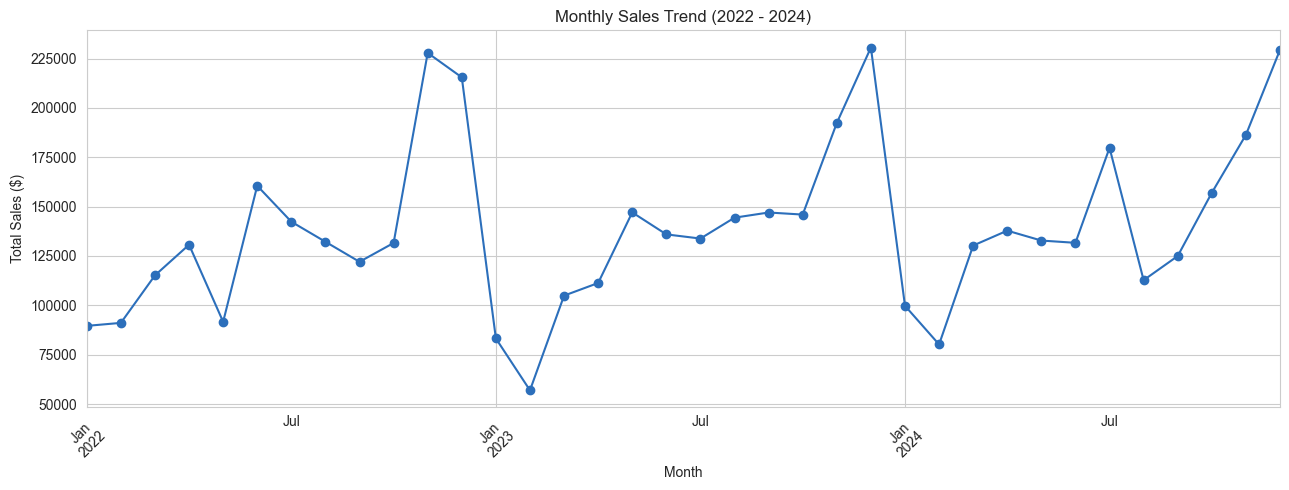

In [10]:
df["Order Month"] = df["Order Date"].dt.to_period("M")
df["Order Quarter"] = df["Order Date"].dt.to_period("Q")

monthly_sales = df.groupby("Order Month")["Sales"].sum()

plt.figure(figsize=(13, 5))
monthly_sales.plot(kind="line", marker="o", color="#2c6fbb")
plt.title("Monthly Sales Trend (2022 - 2024)")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** There's a clear, repeating seasonal pattern - sales dip around **January/February** every year (post-holiday slump, pretty typical for retail) and spike hard in **November/December** (Black Friday + holiday shopping season). The overall level also creeps up a little year over year, which is a good sign for the business.


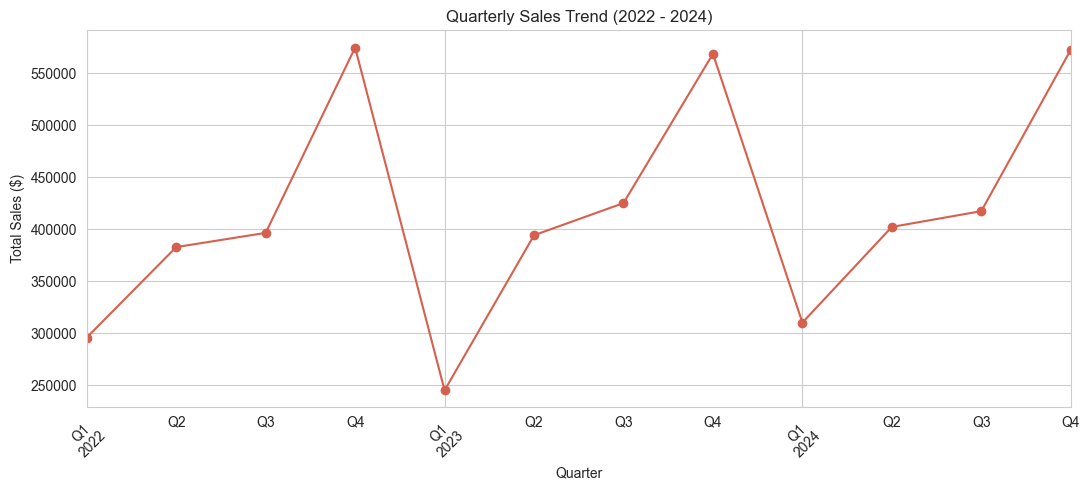

In [11]:
quarterly_sales = df.groupby("Order Quarter")["Sales"].sum()

plt.figure(figsize=(11, 5))
quarterly_sales.plot(kind="line", marker="o", color="#d6604d")
plt.title("Quarterly Sales Trend (2022 - 2024)")
plt.xlabel("Quarter")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** Smoothing it out to quarters makes the pattern even more obvious - **Q4 is the strongest quarter every single year** by a good margin, and **Q1 is consistently the weakest**. This is the kind of pattern a business should plan inventory and staffing around well ahead of time.


## 4. Customer Demographics

Quick look at who's actually buying - age groups and gender split.

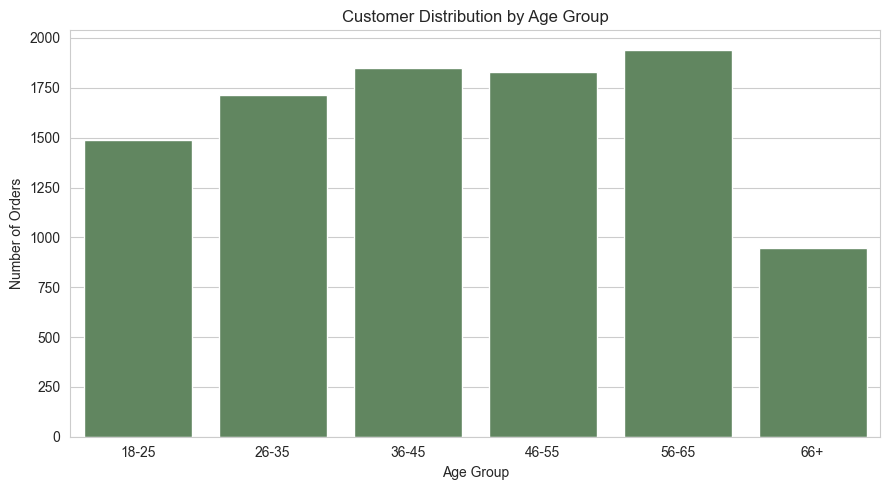

In [12]:
# bucket ages into groups (drop the missing ones just for this chart)
age_df = df.dropna(subset=["Age"]).copy()
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
age_df["Age Group"] = pd.cut(age_df["Age"], bins=bins, labels=labels)

plt.figure(figsize=(9, 5))
sns.countplot(data=age_df, x="Age Group", order=labels, color="#5b8c5a")
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


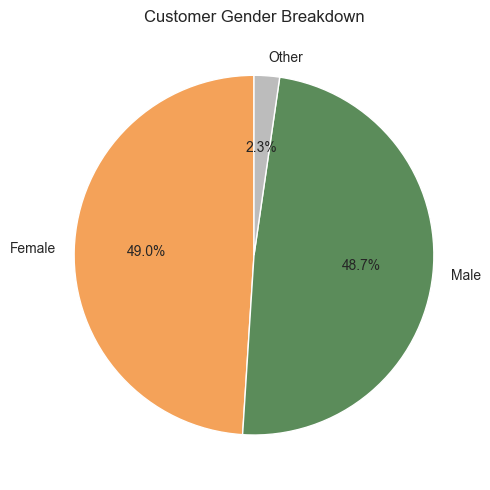

In [13]:
plt.figure(figsize=(6, 5))
gender_counts = df["Gender"].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
        colors=["#f4a259", "#5b8c5a", "#bcbcbc"], startangle=90)
plt.title("Customer Gender Breakdown")
plt.tight_layout()
plt.show()


**Observation:** Orders are spread fairly evenly across age groups, with **26-45 year olds being the biggest chunk** - makes sense as that's usually peak working-age / household-spending age. Gender split is close to 50/50 (Male/Female), with a tiny sliver of "Other" - so this isn't really a gender-skewed customer base, marketing probably shouldn't be gender-targeted here.


## 5. Product Analysis

Which products are actually selling, and which categories bring in the most revenue?

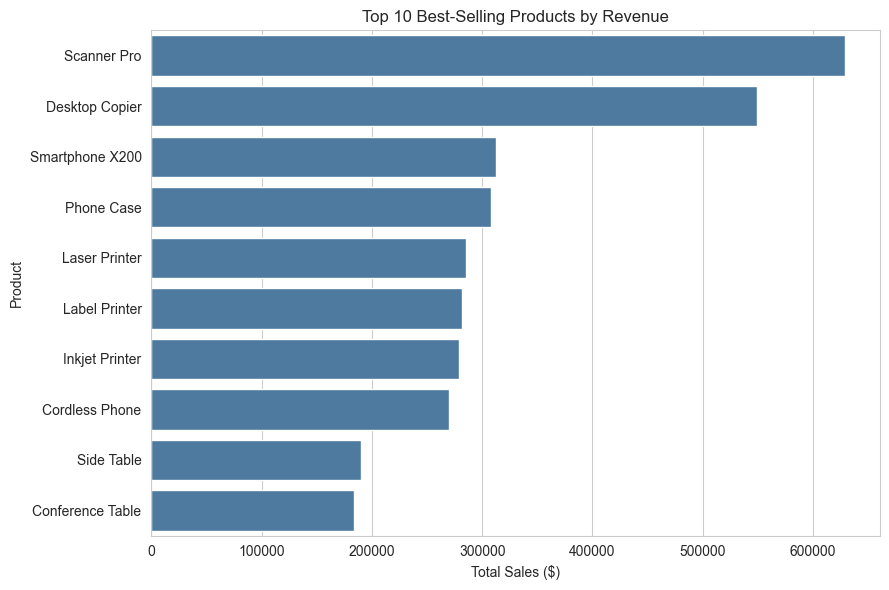

In [14]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_products.values, y=top_products.index, color="#3f7cac")
plt.title("Top 10 Best-Selling Products by Revenue")
plt.xlabel("Total Sales ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


**Observation:** The top 10 list is dominated by the **higher-priced Technology items** (printers, copiers, the smartphone) even though, by sheer order count, Office Supplies items like paper and binders are ordered way more often. Revenue and popularity are not the same thing here - a few expensive items are punching way above their order-count weight.


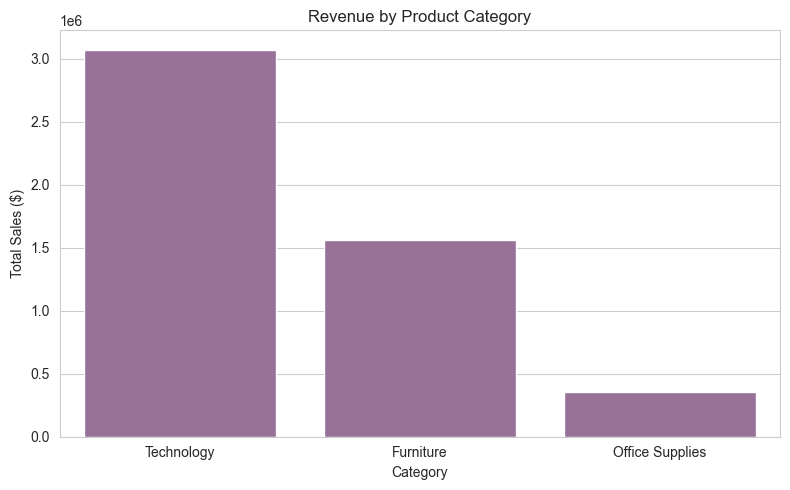

In [15]:
category_revenue = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_revenue.index, y=category_revenue.values, color="#9d6b9e")
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()


**Observation:** **Technology** brings in the most total revenue, followed by Office Supplies, then Furniture. Combined with the earlier profit numbers, this is worth flagging - high revenue doesn't always mean high profit, which I check next.


## 6. Correlation Heatmap

How do the numeric variables relate to each other?

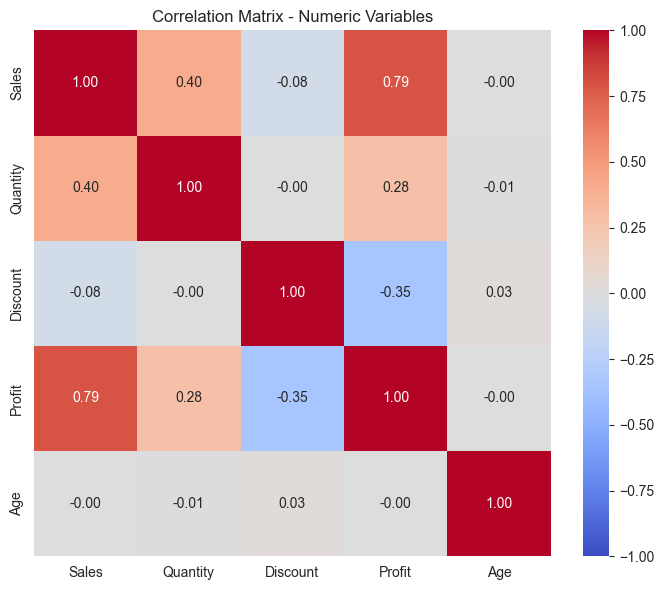

In [16]:
corr_cols = ["Sales", "Quantity", "Discount", "Profit", "Age"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix - Numeric Variables")
plt.tight_layout()
plt.show()


**Observation:**
- **Sales & Profit** are positively correlated (bigger orders generally mean more profit) - expected.
- **Discount & Profit** show a clear **negative correlation** - the more discount given, the lower the profit, sometimes into negative territory. This lines up with the negative `min` profit I saw in the descriptive stats earlier.
- **Age** barely correlates with anything (Sales, Quantity, Discount, Profit) - so age alone isn't a useful predictor of how much someone spends or how profitable their order is, in this dataset.


## 7. Bonus Chart - Discount vs. Profit Margin by Category

This is the one I was most curious about after seeing that discount/profit correlation - *which* category actually gets hurt the most by discounting?

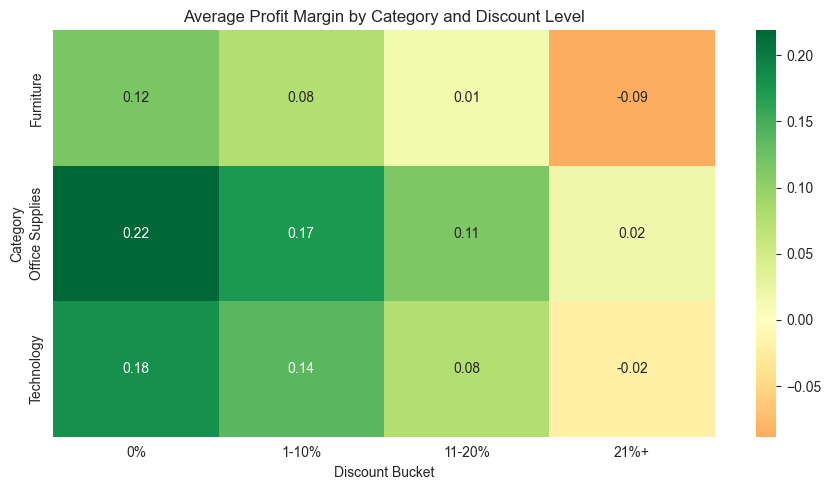

In [17]:
df["Profit Margin"] = df["Profit"] / df["Sales"]

# bucket discounts so the chart isn't too noisy
disc_bins = [-0.01, 0.0, 0.1, 0.2, 0.5]
disc_labels = ["0%", "1-10%", "11-20%", "21%+"]
df["Discount Bucket"] = pd.cut(df["Discount"], bins=disc_bins, labels=disc_labels)

margin_pivot = df.pivot_table(values="Profit Margin", index="Category",
                               columns="Discount Bucket", aggfunc="mean")

plt.figure(figsize=(9, 5))
sns.heatmap(margin_pivot, annot=True, cmap="RdYlGn", center=0, fmt=".2f")
plt.title("Average Profit Margin by Category and Discount Level")
plt.xlabel("Discount Bucket")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


**Observation (the non-obvious one):** This is the most useful chart in the whole notebook, honestly. At 0% discount every category is healthily profitable. But once discount goes above ~20%, **Furniture margins go negative first and fall the hardest** - Technology holds up a bit better, and Office Supplies is in between. So it's not "discounting is bad" in general, it's specifically **deep discounts on Furniture** that are quietly losing the company money. That's not something you'd catch just from looking at total revenue by category.
